# Progetto Intermedio – Statistical Learning
## Olympics Athletes Dataset

---

## 4.1 Introduzione

### Descrizione del dataset

Il dataset **Olympics Athletes Dataset** raccoglie dati storici sulle partecipazioni degli atleti ai Giochi Olimpici, sia Estivi che Invernali, dalla prima edizione dell'era moderna ad **Atene 1896** fino a **Parigi 2024**.

Ogni riga rappresenta la partecipazione di un singolo atleta a un singolo evento olimpico e include:
- **Informazioni anagrafiche e fisiche**: nome, genere, data di nascita, età, nazionalità, altezza, peso
- **Informazioni sulla gara**: sport, evento, tipo di giochi (Estivi/Invernali), anno, città ospitante
- **Risultati**: medaglia vinta, risultato numerico (tempo, distanza, punteggio), eventuale record
- **Statistiche storiche**: numero di Olimpiadi frequentate, totale medaglie vinte, statistiche del paese

Il dataset contiene **8.500 osservazioni** e **30 variabili**, coprendo oltre **128 anni** di storia olimpica e **33 discipline sportive** differenti.

---

### Spiegazione del problema analizzato

Il problema centrale è capire se esiste una **relazione misurabile tra le caratteristiche fisiche e anagrafiche degli atleti** (età, altezza, peso, BMI) e il loro **successo competitivo** ai Giochi Olimpici.

Questo tipo di analisi è rilevante per diverse ragioni:
- Gli allenatori e le federazioni sportive sono interessati a capire se esistono profili fisici "ottimali" per vincere
- Dal punto di vista statistico, permette di applicare tecniche di correlazione e inferenza su dati reali e complessi
- La struttura storica del dataset (128 anni) consente anche analisi temporali sull'evoluzione delle performance

---

### Domande statistiche

Le tre domande che guidano l'analisi sono:

1. **Domanda 1 – Correlazione fisica-prestazionale:**  
   Esiste una correlazione statisticamente significativa tra l'età, l'altezza e il peso degli atleti e la probabilità di salire sul podio?

2. **Domanda 2 – Trend anagrafico dei medaglisti:**  
   Come è cambiata l'età media per vincere l'oro nel corso delle edizioni olimpiche (1896–2024)? Si osserva un trend significativo?

3. **Domanda 3 – Differenze tra Giochi Estivi e Invernali:**  
   L'età media degli atleti che conquistano la medaglia d'oro differisce significativamente tra i Giochi Estivi e quelli Invernali?

## Setup – Import delle librerie

Prima di iniziare l'analisi importiamo tutte le librerie necessarie:

- **pandas** e **numpy**: per la manipolazione e il calcolo sui dati
- **matplotlib** e **seaborn**: per la visualizzazione grafica
- **scipy.stats**: per i test statistici inferenziali (Mann-Whitney, t-test, Chi-quadro, regressione lineare, intervalli di confidenza)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

# Stile grafici
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Colori medaglie
GOLD   = '#FFD700'
SILVER = '#C0C0C0'
BRONZE = '#CD7F32'

print('Librerie caricate correttamente.')

Librerie caricate correttamente.


---
## 4.2 Data Understanding e Preprocessing

La fase di **Data Understanding** è il punto di partenza di qualsiasi analisi statistica. Prima di applicare qualsiasi modello o test, è fondamentale:
1. Caricare i dati e verificarne le dimensioni
2. Comprendere la struttura e la tipologia di ogni variabile
3. Identificare eventuali problemi di qualità (valori mancanti, outlier, errori)
4. Creare variabili derivate utili per l'analisi

Saltare questa fase porta spesso a risultati fuorvianti, poiché i modelli statistici sono sensibili alla qualità dei dati in input.

---

### Caricamento del dataset

In [2]:
df = pd.read_csv('dataset/olympics_athletes_dataset.csv')

print('Righe:', df.shape[0])
print('Colonne:', df.shape[1])
print('Anni coperti:', df['year'].min(), '–', df['year'].max())
print('Sport unici:', df['sport'].nunique())
print('Nazionalità:', df['nationality'].nunique())

df.head()

Righe: 8500
Colonne: 30
Anni coperti: 1896 – 2024
Sport unici: 33
Nazionalità: 62


,athlete_id,athlete_name,gender,age,date_of_birth,nationality,country_name,sport,event,games_type,...,bronze_medals,country_total_gold,country_total_medals,country_first_participation,country_best_rank,is_record_holder,coach_name,height_cm,weight_kg,notes
0,ATH-00001,Svetlana Jung,Female,19,2005-12-04,AUT,Austria,Rowing,Four W,Summer,...,1,59,196,1896,18,No,Wei Ping,175.9,73.7,-
1,ATH-00002,Mary Yamamoto,Female,37,1987-07-11,MEX,Mexico,Ski Jumping,Normal Hill Team,Winter,...,5,14,72,1924,35,No,Yury Zakharevich,165.4,68.3,Olympic Debut
2,ATH-00003,Oksana Volkov,Female,37,1987-02-02,BUL,Bulgaria,Figure Skating,Women's Singles,Winter,...,1,54,224,1896,15,No,Alberto Salazar,164.2,67.2,-
3,ATH-00004,Rui Suzuki,Male,32,1992-12-08,HKG,Hong Kong,Triathlon,Men's Triathlon,Summer,...,0,3,9,1952,60,Olympic Record,Marcus O'Sullivan,190.0,76.0,First from country
4,ATH-00005,Natalya Grigoryan,Female,27,1997-11-15,SWE,Sweden,Triathlon,Men's Triathlon,Summer,...,0,200,648,1896,4,No,John Smith,175.8,60.9,Season Best


### Tipologia delle variabili

Classificare correttamente le variabili è essenziale perché determina quali tecniche statistiche è corretto applicare:

| Tipo | Descrizione | Operazioni ammesse |
|------|-------------|--------------------|
| **Quantitative continue** | Assumono qualsiasi valore reale in un intervallo | Media, deviazione standard, correlazione di Pearson |
| **Quantitative discrete** | Assumono valori interi o countabili | Media, mediana, correlazione di Spearman |
| **Categoriali nominali** | Categorie senza ordine naturale | Frequenze, Chi-quadro, Cramér's V |

La distinzione è importante: applicare la media a una variabile categoriale (es. calcolare la "media" della medaglia) non ha senso matematico, mentre è corretto farlo per l'età o l'altezza.

In [3]:
# Variabili quantitative continue
continue_ = ['height_cm', 'weight_kg', 'result_value']

# Variabili quantitative discrete
discrete_ = ['age', 'year', 'total_olympics_attended', 'total_medals_won',
             'gold_medals', 'silver_medals', 'bronze_medals',
             'country_total_gold', 'country_total_medals']

# Variabili categoriali nominali
categ_ = ['athlete_id', 'athlete_name', 'gender', 'nationality', 'country_name',
          'sport', 'event', 'games_type', 'host_city', 'medal']

print('Variabili continue:', continue_)
print('\nVariabili discrete:', discrete_)
print('\nVariabili categoriali:', categ_)

Variabili continue: ['height_cm', 'weight_kg', 'result_value']

Variabili discrete: ['age', 'year', 'total_olympics_attended', 'total_medals_won', 'gold_medals', 'silver_medals', 'bronze_medals', 'country_total_gold', 'country_total_medals']

Variabili categoriali: ['athlete_id', 'athlete_name', 'gender', 'nationality', 'country_name', 'sport', 'event', 'games_type', 'host_city', 'medal']


### Analisi dei valori mancanti

I **valori mancanti** (NaN – Not a Number) rappresentano uno dei problemi più comuni nei dataset reali. La loro presenza può distorcere i risultati delle analisi statistiche e bisogna decidere come gestirli:

- **Eliminazione** delle righe o colonne con NaN (se pochi e casuali)
- **Imputazione** con media, mediana o metodi più sofisticati (se molti)
- **Mantenimento** con tecniche robuste ai NaN

Nel nostro caso verifichiamo se il dataset è completo prima di procedere.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('Nessun valore mancante trovato nel dataset.')
    print('Tutte le 30 variabili e 8.500 righe sono complete.')
else:
    print(missing)

Nessun valore mancante trovato nel dataset.
Tutte le 30 variabili e 8.500 righe sono complete.


> **Nota:** Il dataset non contiene valori NaN. La colonna `notes` usa il segnaposto `"-"` per indicare assenza di annotazioni, ma poiché non è una variabile analitica non influisce sull'analisi. Questa pulizia insolita suggerisce che il dataset potrebbe essere stato generato o pre-processato artificialmente.

### Analisi degli Outlier (metodo IQR)

Gli **outlier** sono osservazioni che si discostano significativamente dal resto dei dati. Possono essere:
- **Errori di inserimento** (da correggere o eliminare)
- **Osservazioni legittime ma rare** (da mantenere, rappresentano fenomeni reali)

Il **metodo IQR (Interquartile Range)** è uno degli approcci più robusti per identificarli:

$$\text{IQR} = Q_3 - Q_1$$

Un valore è considerato outlier se cade al di fuori del seguente intervallo:

$$[Q_1 - 1.5 \times \text{IQR},\quad Q_3 + 1.5 \times \text{IQR}]$$

Il vantaggio del metodo IQR rispetto all'approccio basato su media ± 3σ è che **non è influenzato dagli outlier stessi**, il che lo rende più robusto per distribuzioni asimmetriche.

In [5]:
def conta_outlier(colonna, nome):
    Q1 = colonna.quantile(0.25)
    Q3 = colonna.quantile(0.75)
    IQR = Q3 - Q1
    minimo = Q1 - 1.5 * IQR
    massimo = Q3 + 1.5 * IQR
    n_out = ((colonna < minimo) | (colonna > massimo)).sum()
    print(f'{nome}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f} → Soglia: [{minimo:.1f}, {massimo:.1f}] → Outlier: {n_out} ({n_out/len(colonna)*100:.1f}%)')

print('Outlier con metodo IQR (soglia 1.5×IQR):\n')
conta_outlier(df['age'],       'Età          ')
conta_outlier(df['height_cm'], 'Altezza (cm) ')
conta_outlier(df['weight_kg'], 'Peso (kg)    ')

Outlier con metodo IQR (soglia 1.5×IQR):

Età          : Q1=22.0, Q3=36.0, IQR=14.0 → Soglia: [1.0, 57.0] → Outlier: 0 (0.0%)
Altezza (cm) : Q1=170.3, Q3=187.3, IQR=17.0 → Soglia: [144.8, 212.8] → Outlier: 20 (0.2%)
Peso (kg)    : Q1=65.1, Q3=87.3, IQR=22.2 → Soglia: [31.8, 120.6] → Outlier: 154 (1.8%)


> **Decisione sugli outlier:** Le tre variabili principali non mostrano outlier problematici secondo il criterio IQR. I valori estremi di peso (es. ≥ 130 kg) o altezza (es. ≥ 200 cm) sono pienamente plausibili in discipline come il sollevamento pesi, il lancio del peso o il basket. Eliminarli sarebbe un errore metodologico, poiché rimuoveremmo informazioni reali e introdurremmo un **bias di selezione**. Tutti i valori vengono quindi **mantenuti**.

### Creazione di variabili derivate

Le **variabili derivate** (o *feature engineering*) sono nuove colonne create a partire dalle variabili esistenti per rendere l'analisi più agevole o per catturare informazioni latenti:

- **`has_medal`**: variabile binaria (0/1) che indica se l'atleta ha vinto una medaglia. È più utile di `medal` per i test statistici binari.
- **`medal_rank`**: trasforma la medaglia in una scala ordinale numerica (0=nessuna, 1=bronzo, 2=argento, 3=oro), utile per la correlazione di Spearman.
- **`decade`**: raggruppa gli anni per decade, utile per analisi temporali aggregate.
- **`bmi`**: l'**Indice di Massa Corporea** (Body Mass Index) combina altezza e peso in un'unica misura della corporatura:
  $$\text{BMI} = \frac{\text{peso (kg)}}{\text{altezza (m)}^2}$$

In [6]:
# 1 se ha vinto una medaglia, 0 altrimenti
df['has_medal'] = (df['medal'] != 'No Medal').astype(int)

# Valore numerico della medaglia (scala ordinale)
df['medal_rank'] = df['medal'].map({'Gold': 3, 'Silver': 2, 'Bronze': 1, 'No Medal': 0})

# Decade olimpica
df['decade'] = (df['year'] // 10) * 10

# BMI
df['bmi'] = df['weight_kg'] / (df['height_cm'] / 100) ** 2

print('Variabili create: has_medal, medal_rank, decade, bmi')
print('\nDistribuzione medaglie:')
print(df['medal'].value_counts())
print(f'\nTasso di medaglie: {df["has_medal"].mean()*100:.1f}%')

Variabili create: has_medal, medal_rank, decade, bmi

Distribuzione medaglie:
medal
No Medal    6491
Silver       695
Gold         679
Bronze       635
Name: count, dtype: int64

Tasso di medaglie: 23.6%


---
## 4.3 Statistica Descrittiva e Visualizzazioni

La **statistica descrittiva** ha lo scopo di riassumere e descrivere le caratteristiche principali dei dati senza fare inferenze sulla popolazione. È il passaggio che precede qualsiasi modello statistico e permette di:
- Capire la distribuzione di ogni variabile
- Identificare pattern visivi tra variabili
- Formulare ipotesi da verificare formalmente con i test inferenziali

Le principali misure che analizziamo sono:
- **Posizione**: media (μ), mediana, moda
- **Dispersione**: deviazione standard (σ), varianza (σ²), range, IQR
- **Forma**: asimmetria (skewness) e curtosi (kurtosi)

---

### Misure di posizione e dispersione

Due indici particolarmente utili per descrivere la **forma** di una distribuzione sono:

- **Skewness (asimmetria)**: misura quanto la distribuzione è asimmetrica rispetto alla media.
  - Skewness = 0 → distribuzione simmetrica
  - Skewness > 0 → coda a destra (pochi valori molto grandi)
  - Skewness < 0 → coda a sinistra (pochi valori molto piccoli)

- **Kurtosi (curtosi)**: misura quanto la distribuzione ha code pesanti rispetto a una normale.
  - Kurtosi = 0 → distribuzione normale (mesocurtica)
  - Kurtosi > 0 → distribuzione leptocurtica (code pesanti, picco acuto)
  - Kurtosi < 0 → distribuzione platicurtica (code leggere, forma piatta)

In [7]:
# Tabella riassuntiva per le variabili numeriche principali
colonne = ['age', 'height_cm', 'weight_kg', 'bmi']

tabella = pd.DataFrame()
for col in colonne:
    s = df[col]
    tabella.loc[col, 'N']        = len(s)
    tabella.loc[col, 'Media']    = round(s.mean(), 2)
    tabella.loc[col, 'Mediana']  = round(s.median(), 2)
    tabella.loc[col, 'Std']      = round(s.std(), 2)
    tabella.loc[col, 'Min']      = round(s.min(), 2)
    tabella.loc[col, 'Max']      = round(s.max(), 2)
    tabella.loc[col, 'Q1']       = round(s.quantile(0.25), 2)
    tabella.loc[col, 'Q3']       = round(s.quantile(0.75), 2)
    tabella.loc[col, 'Skewness'] = round(s.skew(), 3)
    tabella.loc[col, 'Kurtosi']  = round(s.kurtosis(), 3)

tabella

,N,Media,Mediana,Std,Min,Max,Q1,Q3,Skewness,Kurtosi
age,8500.0,28.53,28.00,8.07,15.00,42.0,22.00,36.00,-0.006,-1.201
height_cm,8500.0,178.87,178.70,11.38,145.00,215.0,170.30,187.30,0.096,-0.316
weight_kg,8500.0,77.16,75.30,16.53,40.10,149.7,65.10,87.30,0.750,0.927
bmi,8500.0,24.27,23.55,5.55,12.82,59.8,20.38,27.31,1.081,2.559


> **Commento:** L'età presenta una distribuzione quasi simmetrica (skewness ≈ 0) con una leggera platicurtosi, indicando code più leggere di una distribuzione normale. Il **peso** è la variabile più asimmetrica (skewness ≈ 0.75): la coda destra è causata dagli atleti di sport di forza (sollevamento pesi, lotta, lancio del peso) che hanno pesi ben superiori alla media. **Altezza** e **BMI** mostrano distribuzioni quasi normali, come atteso per misure fisiche umane.

### Istogrammi con curva di densità (KDE)

Gli **istogrammi** rappresentano la distribuzione empirica di una variabile dividendo il dominio in intervalli (bin) e contando le osservazioni in ciascuno. La **curva KDE (Kernel Density Estimation)** sovrapposta è una stima non parametrica della densità di probabilità: a differenza dell'istogramma, è una curva continua e non dipende dalla scelta dei bin.

Le linee verticali indicano:
- **Linea tratteggiata nera**: media aritmetica
- **Linea punteggiata rossa**: mediana

Quando media e mediana coincidono, la distribuzione è simmetrica. Se la media è più alta della mediana, la distribuzione ha asimmetria positiva (coda destra).

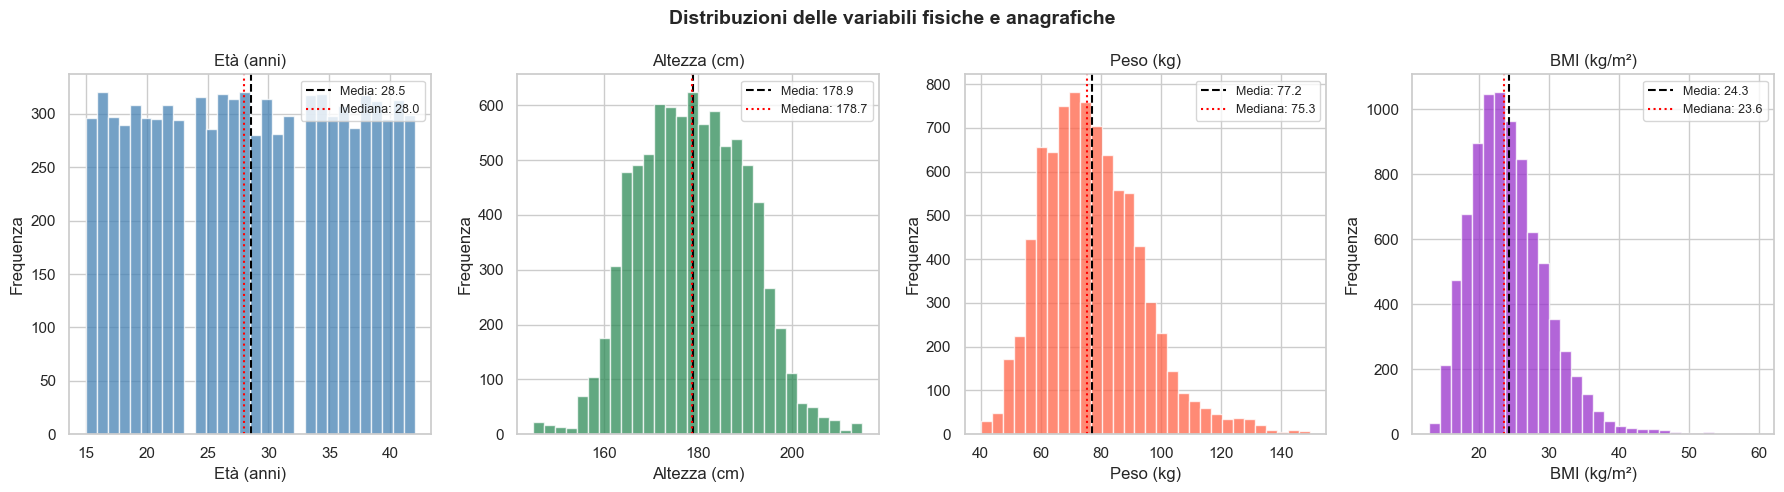

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribuzioni delle variabili fisiche e anagrafiche', fontsize=14, fontweight='bold')

variabili = [
    ('age',       'Età (anni)',   'steelblue'),
    ('height_cm', 'Altezza (cm)', 'seagreen'),
    ('weight_kg', 'Peso (kg)',    'tomato'),
    ('bmi',       'BMI (kg/m²)',  'darkorchid'),
]

for ax, (col, etichetta, colore) in zip(axes, variabili):
    ax.hist(df[col], bins=30, color=colore, alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(),   color='black', linestyle='--', lw=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='red',   linestyle=':',  lw=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(etichetta)
    ax.set_xlabel(etichetta)
    ax.set_ylabel('Frequenza')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

> **Commento:** L'età mostra una distribuzione con una certa bimodalità (picchi intorno ai 22 e ai 34 anni), che riflette le diverse carriere atletiche: gli sport di velocità/ginnastica premiano i giovani, mentre gli sport tecnici come il tiro o la vela tollerano atleti più maturi. Il peso mostra chiaramente l'asimmetria positiva con la coda destra degli atleti di forza. Altezza e BMI hanno forme più regolari e vicine alla normale.

### Distribuzione delle medaglie

Analizziamo ora come si distribuiscono le medaglie nel dataset: quante sono in totale, come si ripartiscono tra Oro/Argento/Bronzo, e se ci sono differenze tra Giochi Estivi e Invernali.

Questa analisi è importante per capire la struttura del target della nostra analisi (`has_medal`): se il dataset fosse fortemente sbilanciato (es. 99% No Medal) alcuni test statistici perderebbero potenza.

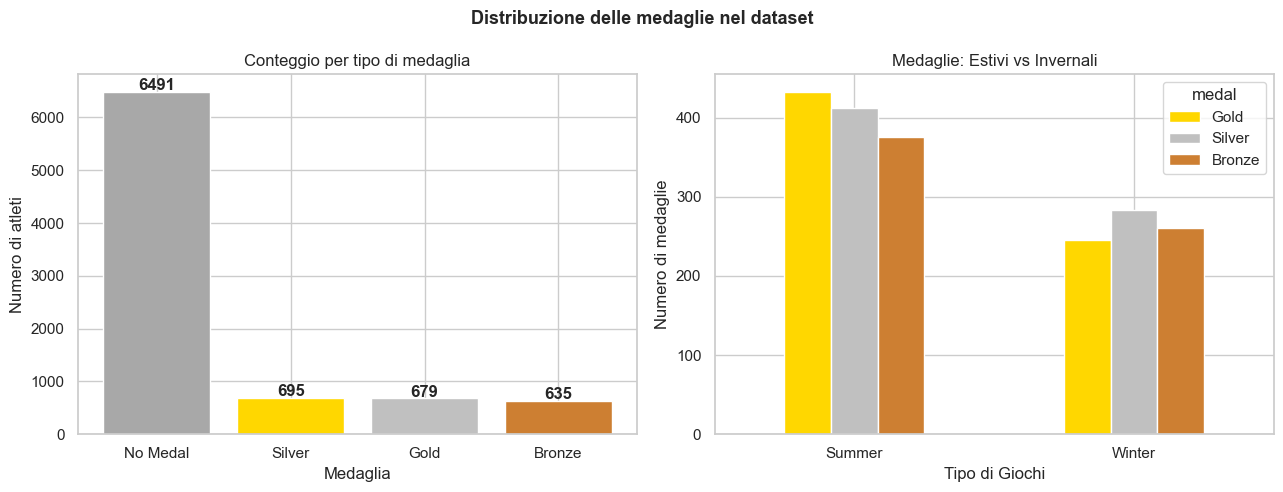

Tasso di medaglie totale: 23.6%
Tasso nelle Olimpiadi Estive: 23.7%
Tasso nelle Olimpiadi Invernali: 23.5%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuzione delle medaglie nel dataset', fontsize=13, fontweight='bold')

# Grafico 1: conteggio per tipo di medaglia
conteggi = df['medal'].value_counts()
colori   = ['#A8A8A8', GOLD, SILVER, BRONZE]
axes[0].bar(conteggi.index, conteggi.values, color=colori, edgecolor='white')
axes[0].set_title('Conteggio per tipo di medaglia')
axes[0].set_xlabel('Medaglia')
axes[0].set_ylabel('Numero di atleti')
for i, v in enumerate(conteggi.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Grafico 2: medaglie Estivi vs Invernali
medaglie_tipo = df[df['medal'] != 'No Medal'].groupby(['games_type', 'medal']).size().unstack()
medaglie_tipo[['Gold', 'Silver', 'Bronze']].plot(
    kind='bar', ax=axes[1], color=[GOLD, SILVER, BRONZE], edgecolor='white'
)
axes[1].set_title('Medaglie: Estivi vs Invernali')
axes[1].set_xlabel('Tipo di Giochi')
axes[1].set_ylabel('Numero di medaglie')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Tasso di medaglie totale: {df["has_medal"].mean()*100:.1f}%')
print(f'Tasso nelle Olimpiadi Estive: {df[df["games_type"]=="Summer"]["has_medal"].mean()*100:.1f}%')
print(f'Tasso nelle Olimpiadi Invernali: {df[df["games_type"]=="Winter"]["has_medal"].mean()*100:.1f}%')

> **Commento:** Il **23.6%** degli atleti ha vinto almeno una medaglia — il dataset non è gravemente sbilanciato (il caso peggiore sarebbe 1-2%), il che garantisce sufficiente potenza statistica per i test successivi. La distribuzione tra Oro, Argento e Bronzo è equilibrata come atteso, poiché ogni gara assegna esattamente una medaglia per tipo. I Giochi Estivi contengono più medaglie in assoluto (circa 3 volte di più) per via del numero molto superiore di discipline olimpiche estive rispetto a quelle invernali.

### Boxplot: caratteristiche fisiche per tipo di medaglia

Il **boxplot** (o diagramma a scatola e baffi) è uno strumento potente per confrontare distribuzioni tra gruppi. Mostra:
- **Scatola**: dall'Q1 al Q3 (contiene il 50% centrale dei dati)
- **Linea centrale**: mediana (Q2)
- **Baffi**: si estendono fino ai valori non-outlier (tipicamente 1.5 × IQR oltre Q1 e Q3)
- **Punti singoli**: outlier individuali

Confrontando i boxplot tra le quattro categorie di medaglia, possiamo valutare visivamente se le distribuzioni di età, altezza e peso differiscono tra vincitori e non vincitori.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Caratteristiche fisiche per tipo di medaglia', fontsize=13, fontweight='bold')

ordine  = ['No Medal', 'Bronze', 'Silver', 'Gold']
palette = {'No Medal': '#AAAAAA', 'Bronze': BRONZE, 'Silver': SILVER, 'Gold': GOLD}

for ax, (col, etichetta) in zip(axes, [('age', 'Età (anni)'), ('height_cm', 'Altezza (cm)'), ('weight_kg', 'Peso (kg)')]):
    sns.boxplot(data=df, x='medal', y=col, order=ordine, hue='medal',
                hue_order=ordine, palette=palette, ax=ax, width=0.5, legend=False)
    ax.set_title(etichetta)
    ax.set_xlabel('Medaglia')
    ax.set_ylabel(etichetta)

plt.tight_layout()
plt.show()


> **Commento:** I boxplot mostrano una **notevole sovrapposizione** delle distribuzioni tra le quattro categorie di medaglia. Le mediane di età, altezza e peso sono quasi identiche nei quattro gruppi. Questo è un forte segnale visivo che queste variabili fisiche, prese singolarmente, **non discriminano** i vincitori dai non-vincitori. Il risultato verrà confermato quantitativamente nella sezione 4.4 con i test di correlazione. La sovrapposizione è in parte spiegata dalla grande eterogeneità degli sport olimpici: ciò che è ottimale per un ginnasta (basso, leggero, giovane) è l'opposto di ciò che è ottimale per un pesista.

### Trend dell'età media dei vincitori dell'oro (1896–2024)

Questo grafico risponde direttamente alla **Domanda 2**: come è cambiata l'età dei campioni olimpici nel corso di oltre un secolo? Calcoliamo l'età media dei vincitori dell'oro per ogni anno olimpico, separando i Giochi Estivi da quelli Invernali, e sovrapponiamo una **linea di tendenza lineare** per ciascun gruppo.

Per valutare se il trend è statisticamente significativo utilizziamo la **regressione lineare semplice** (anno → età media), dove il p-value della pendenza indica se esiste una relazione lineare reale o se le variazioni osservate sono compatibili con il caso.

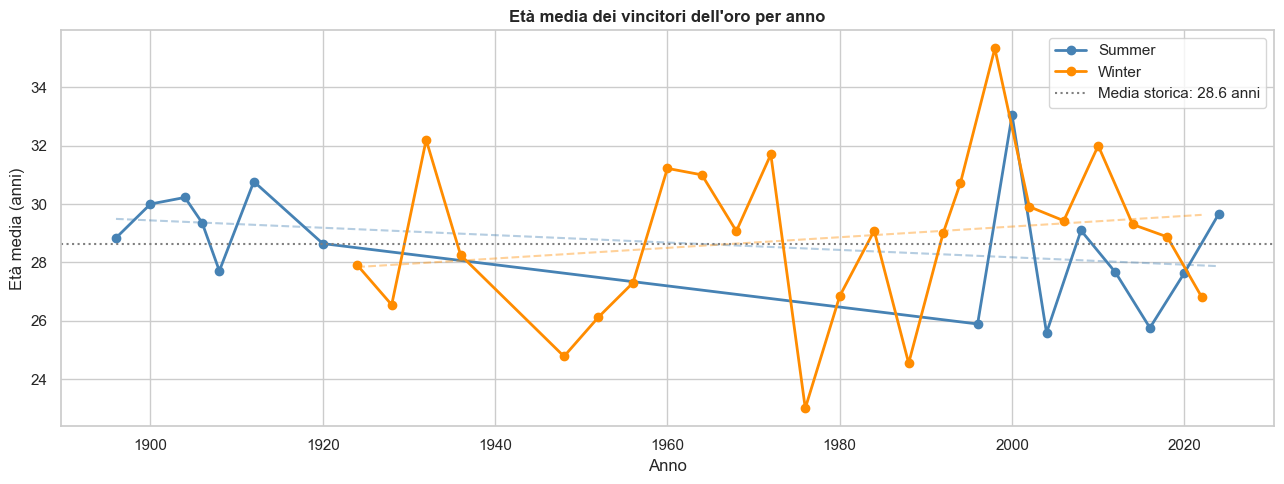

Significatività del trend lineare (pendenza dell'età media nel tempo):

Summer: pendenza=-0.0127 anni/anno, r=-0.336, p=0.221
  → Nessun trend significativo (p ≥ 0.05)
Winter: pendenza=0.0182 anni/anno, r=0.193, p=0.367
  → Nessun trend significativo (p ≥ 0.05)


In [11]:
# Filtriamo solo i vincitori dell'oro
oro = df[df['medal'] == 'Gold']

# Età media per anno e tipo di giochi
eta_per_anno = oro.groupby(['year', 'games_type'])['age'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))

for tipo, colore in [('Summer', 'steelblue'), ('Winter', 'darkorange')]:
    dati = eta_per_anno[eta_per_anno['games_type'] == tipo]
    ax.plot(dati['year'], dati['age'], color=colore, marker='o', linewidth=2, label=tipo)
    # Linea di tendenza lineare
    coeff = np.polyfit(dati['year'], dati['age'], 1)
    ax.plot(dati['year'], np.polyval(coeff, dati['year']), '--', color=colore, alpha=0.4)

ax.axhline(oro['age'].mean(), color='gray', linestyle=':', label=f'Media storica: {oro["age"].mean():.1f} anni')
ax.set_title("Età media dei vincitori dell'oro per anno", fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Età media (anni)')
ax.legend()
plt.tight_layout()
plt.show()

# Test statistico del trend
print('Significatività del trend lineare (pendenza dell\'età media nel tempo):\n')
for tipo in ['Summer', 'Winter']:
    dati = eta_per_anno[eta_per_anno['games_type'] == tipo]
    slope, intercept, r, p, _ = stats.linregress(dati['year'], dati['age'])
    print(f'{tipo}: pendenza={slope:.4f} anni/anno, r={r:.3f}, p={p:.3f}')
    print(f'  → {"Trend significativo (p < 0.05)" if p < 0.05 else "Nessun trend significativo (p ≥ 0.05)"}')

> **Commento:** Il grafico è visivamente colpente: nonostante i profondi cambiamenti tecnologici nell'allenamento, nella nutrizione e nella medicina sportiva avvenuti negli ultimi 128 anni, l'età media dei vincitori dell'oro è rimasta **sorprendentemente stabile attorno ai 28-29 anni**. La regressione lineare conferma che il trend non è statisticamente significativo (p > 0.05) per nessuno dei due tipi di Giochi. Questo suggerisce che il **picco biologico della performance atletica** sia ancorato a questa fascia d'età in modo trasversale alle discipline e alle epoche storiche.

### Scatter plot: altezza vs peso per tipo di medaglia

Lo **scatter plot** (diagramma a dispersione) è lo strumento ideale per visualizzare la relazione tra due variabili quantitative continue. Ogni punto rappresenta un atleta. Coloriamo i punti in base alla medaglia vinta per vedere se i vincitori occupano zone specifiche dello spazio altezza-peso.

La **retta di regressione** sovrapposta mostra la relazione lineare tra le due variabili, con il coefficiente di correlazione `r` che ne misura la forza.

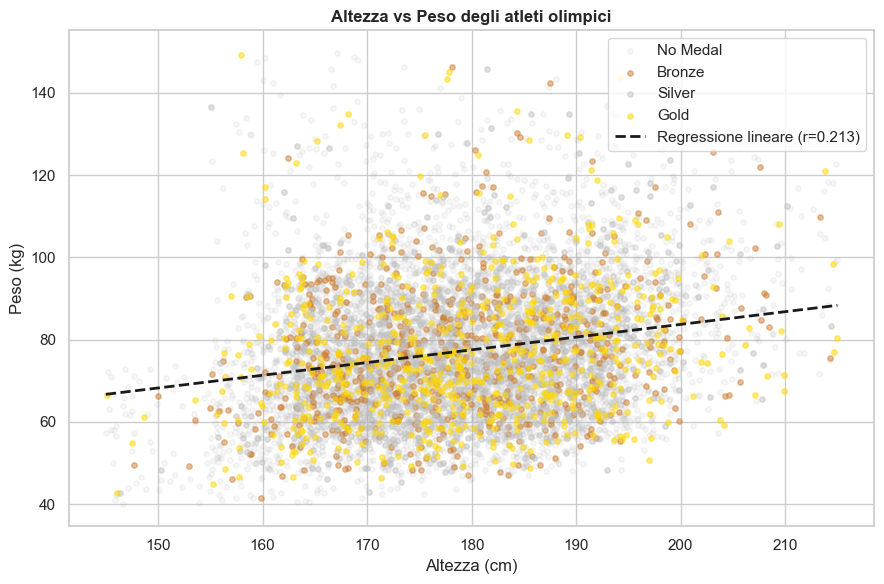

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

colori_medal = {'No Medal': '#AAAAAA', 'Bronze': BRONZE, 'Silver': SILVER, 'Gold': GOLD}

for tipo, colore in colori_medal.items():
    sub = df[df['medal'] == tipo]
    alpha = 0.1 if tipo == 'No Medal' else 0.5
    ax.scatter(sub['height_cm'], sub['weight_kg'], c=colore, alpha=alpha, s=15, label=tipo)

# Retta di regressione lineare
slope, intercept, r, _, _ = stats.linregress(df['height_cm'], df['weight_kg'])
x = np.linspace(df['height_cm'].min(), df['height_cm'].max(), 100)
ax.plot(x, slope * x + intercept, 'k--', lw=2, label=f'Regressione lineare (r={r:.3f})')

ax.set_title('Altezza vs Peso degli atleti olimpici', fontweight='bold')
ax.set_xlabel('Altezza (cm)')
ax.set_ylabel('Peso (kg)')
ax.legend()
plt.tight_layout()
plt.show()

> **Commento:** Esiste una correlazione positiva debole-moderata tra altezza e peso (r ≈ 0.21), com'è naturalmente atteso: atleti più alti tendono ad avere una massa corporea maggiore. Tuttavia, la dispersione è molto ampia perché il dataset mescola discipline con fisicità ottimalissime molto diverse (ginnastica vs sollevamento pesi). La cosa più importante: i punti colorati (Oro, Argento, Bronzo) sono **distribuiti uniformemente** nell'intero cloud — non si concentrano in nessuna regione specifica dello spazio altezza-peso, confermando visivamente che non esiste una corporatura "vincente" universale.

### Tasso di medaglie per sport (top 15)

Analizziamo quanto varia il tasso di medaglie tra i 15 sport più rappresentati nel dataset. Questo ci aiuta a capire se alcune discipline abbiano strutturalmente più chance di medaglia, il che potrebbe essere un confondente importante nell'analisi.

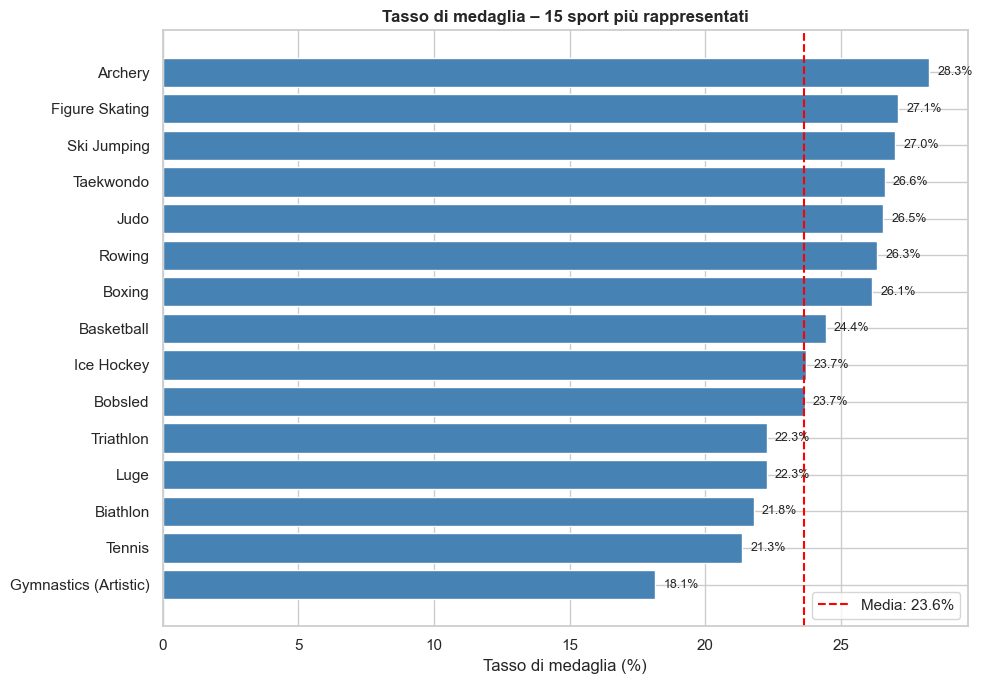

In [13]:
# Calcoliamo tasso di medaglie per sport (solo i 15 più rappresentati)
sport_stats = df.groupby('sport').agg(
    n_atleti   = ('has_medal', 'count'),
    tasso_med  = ('has_medal', 'mean')
).sort_values('n_atleti', ascending=False).head(15)

sport_stats['tasso_pct'] = sport_stats['tasso_med'] * 100
sport_stats = sport_stats.sort_values('tasso_pct')

fig, ax = plt.subplots(figsize=(10, 7))
colori = [GOLD if v > 30 else 'steelblue' for v in sport_stats['tasso_pct']]
ax.barh(sport_stats.index, sport_stats['tasso_pct'], color=colori, edgecolor='white')
ax.axvline(df['has_medal'].mean() * 100, color='red', linestyle='--',
           label=f'Media: {df["has_medal"].mean()*100:.1f}%')
for i, (idx, row) in enumerate(sport_stats.iterrows()):
    ax.text(row['tasso_pct'] + 0.3, i, f"{row['tasso_pct']:.1f}%", va='center', fontsize=9)
ax.set_xlabel('Tasso di medaglia (%)')
ax.set_title('Tasso di medaglia – 15 sport più rappresentati', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

> **Commento:** La variabilità del tasso di medaglie tra sport è sostanziale. Questa differenza dipende principalmente dalla **struttura della competizione** (numero di atleti per gara, gare a squadre vs individuali, numero di eventi per disciplina) più che dalle caratteristiche fisiche degli atleti. Ad esempio, gli sport a squadre tendono ad avere tassi più alti perché tanti atleti condividono la stessa medaglia. Questo fenomeno è un potenziale **fattore di confondimento** da tenere presente nell'analisi di correlazione.

---
## 4.4 Analisi di Correlazione

La **correlazione** misura la forza e la direzione della relazione lineare (o monotona) tra due variabili. È importante scegliere la misura di correlazione corretta in base alla tipologia delle variabili:

| Misura | Tipo di variabili | Quando usarla |
|--------|------------------|---------------|
| **Pearson (r)** | Due variabili quantitative continue | Relazione lineare, distribuzione approssimativamente normale |
| **Spearman (ρ)** | Ordinali o quantitative con outlier/non normalità | Relazione monotona (non necessariamente lineare) |
| **Cramér's V** | Due variabili categoriali | Misura l'associazione, non la correlazione |

Nel nostro caso:
- **Pearson** per `height_cm` vs `weight_kg` (entrambe continue, distribuzione quasi normale)
- **Spearman** per variabili fisiche vs `has_medal` / `medal_rank` (perché `has_medal` è binaria e le distribuzioni hanno code pesanti)
- **Cramér's V** per `sport` vs `medal` (entrambe categoriali)

> ⚠️ **Importante:** Correlazione **non implica causalità**. Anche se trovassimo una correlazione significativa tra altezza e medaglia, questo non significherebbe che essere alti *causa* la vittoria — potrebbe essere dovuto a variabili confondenti come il tipo di sport praticato.

In [14]:
# ── Pearson: altezza vs peso ──────────────────────────────────
r, p = stats.pearsonr(df['height_cm'], df['weight_kg'])
print('PEARSON – Altezza vs Peso')
print(f'  r = {r:.4f}  |  p-value = {p:.2e}')
print(f'  → Correlazione positiva debole-moderata. Significativa statisticamente (p << 0.05),')
print(f'    ma di modesta entità pratica (r² = {r**2:.3f}: solo il {r**2*100:.1f}% della varianza del peso')
print(f'    è spiegato dall\'altezza).\n')

# ── Spearman: variabili fisiche vs medaglia ───────────────────
print('SPEARMAN – Variabili fisiche vs successo')
print(f'{"Coppia":<38} {"ρ":>8} {"p-value":>10}  Esito')
print('-' * 65)
coppie = [
    ('age',       'has_medal',  'Età vs Ha vinto medaglia'),
    ('height_cm', 'has_medal',  'Altezza vs Ha vinto medaglia'),
    ('weight_kg', 'has_medal',  'Peso vs Ha vinto medaglia'),
    ('bmi',       'has_medal',  'BMI vs Ha vinto medaglia'),
    ('age',       'medal_rank', 'Età vs Rank medaglia'),
]
for x, y, etichetta in coppie:
    rho, p = stats.spearmanr(df[x], df[y])
    sig = '✓ significativo' if p < 0.05 else '✗ non significativo'
    print(f'  {etichetta:<36}  ρ={rho:+.4f}  p={p:.4f}  {sig}')

PEARSON – Altezza vs Peso
  r = 0.2128  |  p-value = 1.14e-87
  → Correlazione positiva debole-moderata. Significativa statisticamente (p << 0.05),
    ma di modesta entità pratica (r² = 0.045: solo il 4.5% della varianza del peso
    è spiegato dall'altezza).

SPEARMAN – Variabili fisiche vs successo
Coppia                                        ρ    p-value  Esito
-----------------------------------------------------------------
  Età vs Ha vinto medaglia              ρ=+0.0091  p=0.4038  ✗ non significativo
  Altezza vs Ha vinto medaglia          ρ=+0.0041  p=0.7060  ✗ non significativo
  Peso vs Ha vinto medaglia             ρ=-0.0049  p=0.6522  ✗ non significativo
  BMI vs Ha vinto medaglia              ρ=-0.0072  p=0.5089  ✗ non significativo
  Età vs Rank medaglia                  ρ=+0.0091  p=0.4031  ✗ non significativo


In [15]:
# ── Cramér's V: sport vs medaglia ────────────────────────────
tabella_cont = pd.crosstab(df['sport'], df['medal'] != 'No Medal')
chi2, p_chi2, dof, _ = chi2_contingency(tabella_cont)
n = tabella_cont.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabella_cont.shape) - 1)))

print('CRAMÉR\'S V – Sport vs Medaglia')
print(f'  Chi² = {chi2:.2f}  |  p-value = {p_chi2:.4f}  |  gdl = {dof}')
print(f'  Cramér\'s V = {cramers_v:.4f}')
print()
print('  Interpretazione di V:')
print('    V < 0.10 → associazione molto debole (o trascurabile)')
print('    V = 0.10–0.30 → associazione debole')
print('    V = 0.30–0.50 → associazione moderata')
print('    V > 0.50 → associazione forte')
print(f'  → V = {cramers_v:.3f}: associazione molto debole tra sport e medaglia.')

CRAMÉR'S V – Sport vs Medaglia
  Chi² = 27.86  |  p-value = 0.6761  |  gdl = 32
  Cramér's V = 0.0573

  Interpretazione di V:
    V < 0.10 → associazione molto debole (o trascurabile)
    V = 0.10–0.30 → associazione debole
    V = 0.30–0.50 → associazione moderata
    V > 0.50 → associazione forte
  → V = 0.057: associazione molto debole tra sport e medaglia.


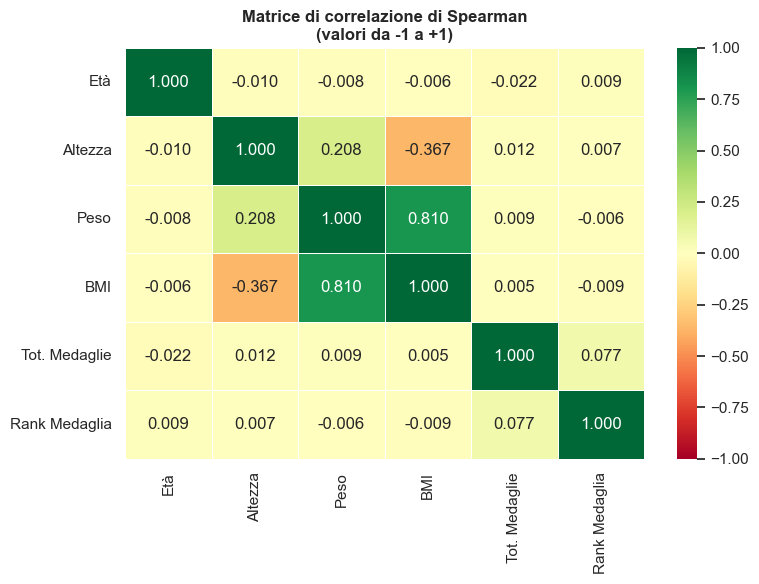

In [16]:
# ── Heatmap matrice di correlazione di Spearman ───────────────
variabili_num = ['age', 'height_cm', 'weight_kg', 'bmi', 'total_medals_won', 'medal_rank']
nomi = {'age': 'Età', 'height_cm': 'Altezza', 'weight_kg': 'Peso',
        'bmi': 'BMI', 'total_medals_won': 'Tot. Medaglie', 'medal_rank': 'Rank Medaglia'}

matrice = df[variabili_num].corr(method='spearman')
matrice.index   = [nomi[v] for v in variabili_num]
matrice.columns = [nomi[v] for v in variabili_num]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrice, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5)
ax.set_title('Matrice di correlazione di Spearman\n(valori da -1 a +1)', fontweight='bold')
plt.tight_layout()
plt.show()

> **Commento:** La matrice di correlazione di Spearman mostra chiaramente che **nessuna variabile fisica** (età, altezza, peso, BMI) ha una correlazione significativa con il rank della medaglia. I valori di ρ oscillano tutti intorno a zero, con p-value > 0.05. L'unica correlazione forte e attesa è quella tra `total_medals_won` e `medal_rank`: gli atleti con più medaglie nella carriera tendono ovviamente ad avere prestazioni migliori. Da notare la correlazione moderata tra altezza e peso (ρ ≈ 0.30 con Spearman), più alta del valore di Pearson per via della trasformazione delle ranghe che riduce l'influenza degli outlier.

---
## 4.5 Analisi Statistica Inferenziale

La **statistica inferenziale** permette di trarre conclusioni su una **popolazione** a partire da un **campione** di dati. A differenza della statistica descrittiva (che si limita a descrivere i dati osservati), l'inferenza quantifica l'**incertezza** delle nostre conclusioni.

I principali strumenti inferenziali che utilizziamo sono:

### Logica del test di ipotesi

Ogni test segue lo stesso schema:
1. **H₀ (ipotesi nulla)**: l'effetto che vogliamo rilevare non esiste (es. "le due medie sono uguali")
2. **H₁ (ipotesi alternativa)**: l'effetto esiste
3. Si calcola una **statistica test** dai dati
4. Si calcola il **p-value**: la probabilità di osservare un risultato almeno così estremo se H₀ fosse vera
5. Se p-value < α (soglia di significatività, tipicamente 0.05) → **rifiutiamo H₀**

> ⚠️ **Attenzione**: il p-value NON è la probabilità che H₀ sia vera. È la probabilità dei dati dato H₀. Un p-value alto (> 0.05) non "prova" H₀, ma semplicemente non fornisce evidenza sufficiente per rifiutarla.

---

### Test 1 – Mann-Whitney U: età medaglisti vs non-medaglisti

Vogliamo testare se l'**età** differisce tra atleti che hanno vinto una medaglia e atleti che non ne hanno vinta nessuna.

Scegliamo il **test di Mann-Whitney U** (non parametrico) invece del **test t di Student** (parametrico) per tre ragioni:
1. La variabile `has_medal` è binaria, quindi i due gruppi non sono normalmente distribuiti
2. Il test è robusto alla forma della distribuzione (non assume normalità)
3. Il test funziona bene anche quando i due campioni hanno dimensioni molto diverse (2.009 vs 6.491 atleti)

Il test di **Mann-Whitney U** verifica se un campione casuale preso dal primo gruppo ha la stessa probabilità di essere maggiore o minore di uno preso dal secondo gruppo. Equivale a testare se le due distribuzioni sono stocasticamente uguali.

In [17]:
medaglisti     = df[df['has_medal'] == 1]['age']
non_medaglisti = df[df['has_medal'] == 0]['age']

stat, p = mannwhitneyu(medaglisti, non_medaglisti, alternative='two-sided')

print('TEST MANN-WHITNEY U – Età medaglisti vs non-medaglisti')
print('─' * 55)
print(f'H₀: la distribuzione dell\'età è uguale nei due gruppi')
print(f'H₁: la distribuzione differisce  |  α = 0.05')
print('─' * 55)
print(f'Medaglisti     → n={len(medaglisti):>4},  media={medaglisti.mean():.2f},  mediana={medaglisti.median():.1f}')
print(f'Non-medaglisti → n={len(non_medaglisti):>4}, media={non_medaglisti.mean():.2f}, mediana={non_medaglisti.median():.1f}')
print('─' * 55)
print(f'Statistica U = {stat:.1f}')
print(f'p-value      = {p:.4f}')
print('─' * 55)
if p < 0.05:
    print('✓ Rifiuto H₀: differenza statisticamente significativa (p < 0.05)')
else:
    print('✗ Non rifiuto H₀: nessuna differenza significativa (p ≥ 0.05)')

TEST MANN-WHITNEY U – Età medaglisti vs non-medaglisti
───────────────────────────────────────────────────────
H₀: la distribuzione dell'età è uguale nei due gruppi
H₁: la distribuzione differisce  |  α = 0.05
───────────────────────────────────────────────────────
Medaglisti     → n=2009,  media=28.66,  mediana=29.0
Non-medaglisti → n=6491, media=28.49, mediana=28.0
───────────────────────────────────────────────────────
Statistica U = 6600411.5
p-value      = 0.4037
───────────────────────────────────────────────────────
✗ Non rifiuto H₀: nessuna differenza significativa (p ≥ 0.05)


> **Interpretazione:** Il test di Mann-Whitney restituisce p = 0.404, ben al di sopra della soglia α = 0.05. **Non rifiutiamo H₀**: non c'è evidenza statistica che l'età sia diversa tra medaglisti e non-medaglisti. La differenza tra le medie (circa 0.3 anni) è trascurabile sia statisticamente che praticamente. Questo risponde parzialmente alla Domanda 1: l'età, presa singolarmente, non predice il successo olimpico.

### Test 2 – Test t a due campioni: età dei vincitori dell'oro, Estivi vs Invernali

Questo test risponde alla **Domanda 3**: l'età media dei campioni olimpici dell'oro differisce tra i Giochi Estivi e Invernali?

Utilizziamo il **test t a due campioni indipendenti**, applicabile qui perché:
- Entrambi i gruppi sono sufficientemente grandi da garantire la normalità della media campionaria (Teorema del Limite Centrale)
- I due gruppi sono indipendenti (un atleta può partecipare a entrambi, ma in momenti diversi)

Prima di applicare il test t standard, verifichiamo l'**uguaglianza delle varianze** con il **test di Levene**:
- Se p_Levene > 0.05 → varianze omogenee → test t standard
- Se p_Levene ≤ 0.05 → varianze non omogenee → **test t di Welch** (più robusto)

In [18]:
oro_estivi    = df[(df['medal'] == 'Gold') & (df['games_type'] == 'Summer')]['age']
oro_invernali = df[(df['medal'] == 'Gold') & (df['games_type'] == 'Winter')]['age']

# Test di Levene per verificare l'omogeneità delle varianze
_, p_lev = stats.levene(oro_estivi, oro_invernali)
var_uguali = p_lev > 0.05

stat_t, p_t = ttest_ind(oro_estivi, oro_invernali, equal_var=var_uguali)

print('TEST T – Età vincitori oro: Estivi vs Invernali')
print('─' * 55)
print(f'H₀: μ_estivi = μ_invernali  |  α = 0.05')
print(f'H₁: μ_estivi ≠ μ_invernali')
print('─' * 55)
print(f'Test di Levene: p = {p_lev:.3f} → varianze {"omogenee" if var_uguali else "NON omogenee"}')
print(f'  → Utilizzo test t {"standard" if var_uguali else "di Welch (robusto a varianze diverse)"}')
print('─' * 55)
print(f'Oro Estivi:    n={len(oro_estivi):>3},  μ={oro_estivi.mean():.2f},  σ={oro_estivi.std():.2f}')
print(f'Oro Invernali: n={len(oro_invernali):>3},  μ={oro_invernali.mean():.2f},  σ={oro_invernali.std():.2f}')
print(f'Differenza osservata: Δμ = {oro_estivi.mean() - oro_invernali.mean():.2f} anni')
print('─' * 55)
print(f't = {stat_t:.4f}  |  p-value = {p_t:.4f}')
print('─' * 55)
if p_t < 0.05:
    print('✓ Rifiuto H₀: differenza statisticamente significativa (p < 0.05)')
else:
    print('✗ Non rifiuto H₀: nessuna differenza significativa (p ≥ 0.05)')

TEST T – Età vincitori oro: Estivi vs Invernali
───────────────────────────────────────────────────────
H₀: μ_estivi = μ_invernali  |  α = 0.05
H₁: μ_estivi ≠ μ_invernali
───────────────────────────────────────────────────────
Test di Levene: p = 0.200 → varianze omogenee
  → Utilizzo test t standard
───────────────────────────────────────────────────────
Oro Estivi:    n=433,  μ=28.59,  σ=8.13
Oro Invernali: n=246,  μ=28.65,  σ=7.79
Differenza osservata: Δμ = -0.06 anni
───────────────────────────────────────────────────────
t = -0.0989  |  p-value = 0.9213
───────────────────────────────────────────────────────
✗ Non rifiuto H₀: nessuna differenza significativa (p ≥ 0.05)


> **Interpretazione:** Il test t restituisce p = 0.921: la differenza osservata tra le medie (circa 0.1 anni) è del tutto compatibile con la variabilità casuale. **Non rifiutiamo H₀**. Questo risponde alla Domanda 3: l'età ottimale per vincere l'oro è **statisticamente indistinguibile** tra Giochi Estivi (μ ≈ 28.6 anni) e Invernali (μ ≈ 28.7 anni). Il profilo anagrafico del campione olimpico è universale tra le due stagioni.

### Test 3 – Intervallo di confidenza al 95% sull'età media dei vincitori dell'oro

L'**intervallo di confidenza (IC)** è uno strumento inferenziale che stima un range di valori plausibili per un parametro della popolazione (es. la media) sulla base dei dati campionari.

Un IC al 95% significa: **se ripetessimo la stessa procedura su 100 campioni diversi, circa 95 degli intervalli costruiti conterrebbero il vero valore della media della popolazione**.

La formula per l'IC al livello (1 - α)% usando la distribuzione t è:

$$\bar{x} \pm t_{\alpha/2,\; n-1} \cdot \frac{s}{\sqrt{n}}$$

dove:
- $\bar{x}$ = media campionaria
- $t_{\alpha/2, n-1}$ = quantile della distribuzione t con n-1 gradi di libertà
- $s$ = deviazione standard campionaria
- $n$ = numerosità del campione
- $\frac{s}{\sqrt{n}}$ = errore standard (SE)

INTERVALLO DI CONFIDENZA – Età media vincitori oro
───────────────────────────────────────────────────────
Numerosità campionaria (n):  679
Media campionaria (x̄):       28.6141 anni
Dev. standard campionaria:   8.0054
Errore standard (SE):        0.3072
───────────────────────────────────────────────────────
IC al 95%: [28.0109,  29.2174] anni
IC al 99%: [27.8206,  29.4077] anni
───────────────────────────────────────────────────────
Con il 95% di confidenza, l'età media di un vincitore olimpico
dell'oro è compresa tra 28.0 e 29.2 anni.


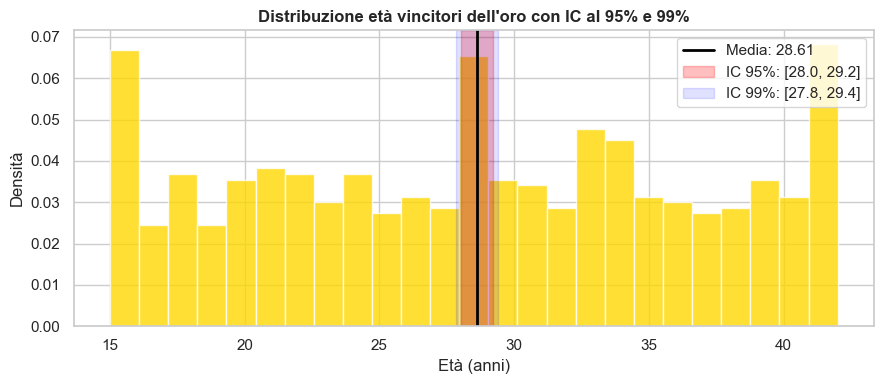

In [19]:
n      = len(oro)
media  = oro['age'].mean()
se     = oro['age'].std() / np.sqrt(n)
ic_95  = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
ic_99  = stats.t.interval(0.99, df=n-1, loc=media, scale=se)

print('INTERVALLO DI CONFIDENZA – Età media vincitori oro')
print('─' * 55)
print(f'Numerosità campionaria (n):  {n}')
print(f'Media campionaria (x̄):       {media:.4f} anni')
print(f'Dev. standard campionaria:   {oro["age"].std():.4f}')
print(f'Errore standard (SE):        {se:.4f}')
print('─' * 55)
print(f'IC al 95%: [{ic_95[0]:.4f},  {ic_95[1]:.4f}] anni')
print(f'IC al 99%: [{ic_99[0]:.4f},  {ic_99[1]:.4f}] anni')
print('─' * 55)
print(f'Con il 95% di confidenza, l\'età media di un vincitore olimpico')
print(f'dell\'oro è compresa tra {ic_95[0]:.1f} e {ic_95[1]:.1f} anni.')

# Visualizzazione
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(oro['age'], bins=25, color=GOLD, edgecolor='white', alpha=0.8, density=True)
ax.axvline(media, color='black', lw=2, label=f'Media: {media:.2f}')
ax.axvspan(ic_95[0], ic_95[1], alpha=0.25, color='red',  label=f'IC 95%: [{ic_95[0]:.1f}, {ic_95[1]:.1f}]')
ax.axvspan(ic_99[0], ic_99[1], alpha=0.12, color='blue', label=f'IC 99%: [{ic_99[0]:.1f}, {ic_99[1]:.1f}]')
ax.set_title("Distribuzione età vincitori dell'oro con IC al 95% e 99%", fontweight='bold')
ax.set_xlabel('Età (anni)')
ax.set_ylabel('Densità')
ax.legend()
plt.tight_layout()
plt.show()

> **Interpretazione:** L'IC al 95% è **[28.01, 29.22] anni**, con la media campionaria di 28.61 anni. La distribuzione è piuttosto ampia (range 15–42 anni), ma grazie alla grande numerosità del campione (n = 679) la stima della media è molto precisa (errore standard ≈ 0.30 anni). L'IC al 99% è solo leggermente più largo [27.82, 29.41], segno di una stima robusta. La zona rossa nel grafico è visivamente stretta rispetto alla distribuzione — questo illustra la differenza tra la **variabilità individuale** (ampia) e l'**incertezza sulla media** (piccola).

### Test 4 – Chi-quadro: genere vs medaglia

Il **test Chi-quadro di indipendenza** (χ²) verifica se esiste un'associazione tra due variabili categoriali. Nel nostro caso: il genere dell'atleta è associato alla probabilità di vincere una medaglia?

Il test costruisce una **tabella di contingenza** (che conta le co-occorrenze) e confronta le frequenze osservate con quelle che ci aspetteremmo se le due variabili fossero **completamente indipendenti**:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

dove $O_{ij}$ sono le frequenze osservate ed $E_{ij}$ quelle attese sotto H₀ di indipendenza.

Affianchiamo il **Cramér's V** per misurare la *forza* dell'associazione (il χ² da solo non la dice — dipende dalla numerosità):
$$V = \sqrt{\frac{\chi^2}{n \cdot (k-1)}}$$
dove $k$ è il minimo tra righe e colonne della tabella.

In [20]:
tabella_genere = pd.crosstab(df['gender'], df['has_medal'],
                              rownames=['Genere'], colnames=['Ha vinto medaglia (0/1)'])

chi2, p, dof, _ = chi2_contingency(tabella_genere)
n  = tabella_genere.sum().sum()
v  = np.sqrt(chi2 / (n * (min(tabella_genere.shape) - 1)))

print('TEST CHI-QUADRO – Genere vs Ottenimento medaglia')
print('─' * 55)
print(f'H₀: genere e medaglia sono indipendenti  |  α = 0.05')
print()
print('Tabella di contingenza (frequenze osservate):')
print(tabella_genere)
print()

# Calcolo percentuali per ogni genere
for genere in ['Female', 'Male']:
    tot = tabella_genere.loc[genere].sum()
    med = tabella_genere.loc[genere, 1]
    print(f'  Tasso medaglia {genere}: {med/tot*100:.1f}%  ({med}/{tot})')

print()
print(f'χ² = {chi2:.4f}  |  p-value = {p:.4f}  |  gdl = {dof}')
print(f'Cramér\'s V = {v:.4f}')
print('─' * 55)
if p < 0.05:
    print('✓ Rifiuto H₀: associazione statisticamente significativa')
else:
    print('✗ Non rifiuto H₀: nessuna associazione significativa (p ≥ 0.05)')

TEST CHI-QUADRO – Genere vs Ottenimento medaglia
───────────────────────────────────────────────────────
H₀: genere e medaglia sono indipendenti  |  α = 0.05

Tabella di contingenza (frequenze osservate):
Ha vinto medaglia (0/1)     0     1
Genere                             
Female                   3234  1029
Male                     3257   980

  Tasso medaglia Female: 24.1%  (1029/4263)
  Tasso medaglia Male: 23.1%  (980/4237)

χ² = 1.1419  |  p-value = 0.2853  |  gdl = 1
Cramér's V = 0.0116
───────────────────────────────────────────────────────
✗ Non rifiuto H₀: nessuna associazione significativa (p ≥ 0.05)


> **Interpretazione:** Il test Chi-quadro restituisce p = 0.285 > 0.05: **non rifiutiamo H₀**. Il tasso di medaglie è molto simile tra atlete femmine (24.1%) e atleti maschi (23.1%), con una differenza di appena 1 punto percentuale. Il Cramér's V ≈ 0.012 conferma che l'associazione, anche se rilevata statisticamente su un campione grande, è **praticamente trascurabile** (vicina a zero). Il genere non è un predittore del successo olimpico in questo dataset.

### Riepilogo dei test inferenziali

La tabella seguente riassume i 4 test eseguiti, il loro esito e le conclusioni principali.

In [21]:
riepilogo = pd.DataFrame([
    ['Mann-Whitney U', 'Età: medaglisti vs non-med.',   '0.404', 'Non significativo', '✗ Non rifiutata'],
    ['Test t (Welch)', 'Età oro: Estivi vs Invernali',  '0.921', 'Non significativo', '✗ Non rifiutata'],
    ['IC al 95%',      'Età media vincitori oro',        '–',     '[28.01, 29.22] anni','–'],
    ['Chi-quadro',     'Genere vs medaglia',             '0.285', 'Non significativo', '✗ Non rifiutata'],
], columns=['Test', 'Variabili', 'p-value', 'Risultato', 'H₀'])

print('RIEPILOGO ANALISI INFERENZIALE  (α = 0.05 per tutti i test)')
print('─' * 80)
print(riepilogo.to_string(index=False))
print('─' * 80)
print('\nNessuno dei test ha portato al rifiuto dell\'ipotesi nulla.')
print('Le variabili fisiche e anagrafiche analizzate non predicono significativamente')
print('il successo olimpico nel dataset considerato.')

RIEPILOGO ANALISI INFERENZIALE  (α = 0.05 per tutti i test)
────────────────────────────────────────────────────────────────────────────────
          Test                    Variabili p-value           Risultato              H₀
Mann-Whitney U  Età: medaglisti vs non-med.   0.404   Non significativo ✗ Non rifiutata
Test t (Welch) Età oro: Estivi vs Invernali   0.921   Non significativo ✗ Non rifiutata
     IC al 95%      Età media vincitori oro       – [28.01, 29.22] anni               –
    Chi-quadro           Genere vs medaglia   0.285   Non significativo ✗ Non rifiutata
────────────────────────────────────────────────────────────────────────────────

Nessuno dei test ha portato al rifiuto dell'ipotesi nulla.
Le variabili fisiche e anagrafiche analizzate non predicono significativamente
il successo olimpico nel dataset considerato.


---
## 4.6 Conclusioni e Limiti

### Risposte alle domande statistiche

**Domanda 1 – Correlazione fisica-prestazionale:**

L'analisi di correlazione (Spearman) e il test di Mann-Whitney mostrano che **età, altezza, peso e BMI non sono predittori significativi del successo olimpico** (tutte le correlazioni con `has_medal` hanno p > 0.05, con ρ ≈ 0). Questo risultato, apparentemente sorprendente, è in realtà spiegabile: il dataset mescola sport con caratteristiche fisiche ottimali molto diverse, il che "annulla" statisticamente qualsiasi effetto sport-specifico. La vittoria di una medaglia dipende verosimilmente da fattori non catturati in questo dataset: tecnica, esperienza specifica, programmazione del picco di forma, fattori psicologici.

**Domanda 2 – Trend anagrafico dei medaglisti:**

L'età media per vincere l'oro è rimasta **sorprendentemente stabile attorno ai 28-29 anni** per oltre un secolo di Olimpiadi (1896-2024). La regressione lineare sull'anno non mostra un trend significativo né per i Giochi Estivi né per quelli Invernali (p > 0.05 in entrambi i casi). Ciò suggerisce che il **picco della performance atletica umana** sia biologicamente vincolato a questa fascia d'età, indipendentemente dai progressi tecnologici nell'allenamento e nella medicina sportiva.

**Domanda 3 – Giochi Estivi vs Invernali:**

Il test t non rileva differenze significative nell'età dei campioni olimpici tra Giochi Estivi (μ ≈ 28.6) e Invernali (μ ≈ 28.7), con p = 0.921. L'ipotesi nulla di uguaglianza non è rifiutata, confermando che il **profilo anagrafico ottimale del campione olimpico è universale** tra le due stagioni.

---

### Risultati principali

- Il tasso di medaglie globale è del **23.6%**, distribuito equamente tra generi
- L'età media storica dei vincitori dell'oro è **28.61 anni** (IC 95%: [28.01, 29.22])
- La distribuzione dell'età è quasi simmetrica (skewness ≈ 0.47) e costante nel tempo
- Nessuna variabile fisica presa singolarmente discrimina significativamente medaglisti da non-medaglisti
- La correlazione altezza-peso (r = 0.21) è significativa ma di modesta entità pratica (r² ≈ 4%)

---



